# **Our Dataset**

Dataset size: 25570


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...


Epoch 3
Train Acc: 0.9446
Val Acc: 0.9126


100%|██████████| 1279/1279 [08:23<00:00,  2.54it/s]



Epoch 4
Train Acc: 0.9629
Val Acc: 0.9187


100%|██████████| 1279/1279 [08:23<00:00,  2.54it/s]



Epoch 5
Train Acc: 0.9761
Val Acc: 0.9177

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      2201
           1       0.93      0.92      0.93      2913

    accuracy                           0.92      5114
   macro avg       0.92      0.92      0.92      5114
weighted avg       0.92      0.92      0.92      5114



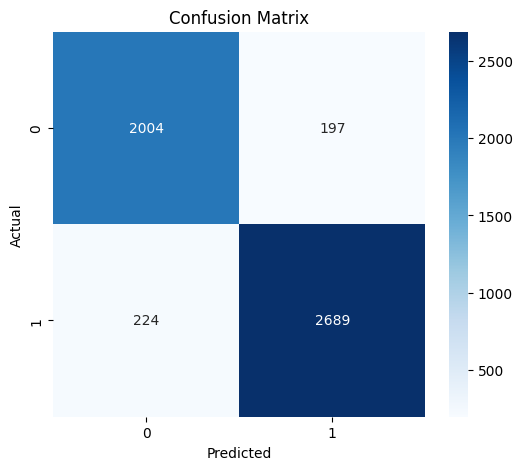

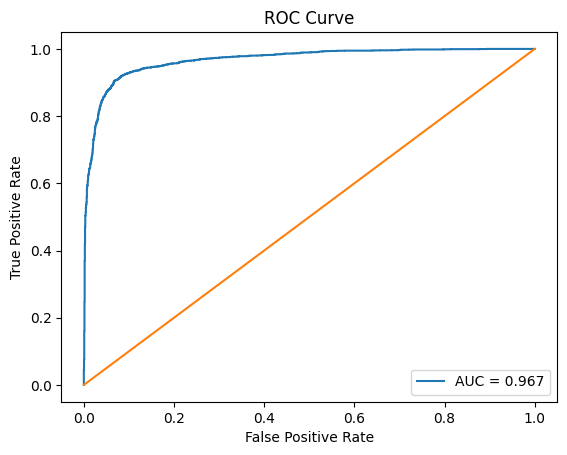

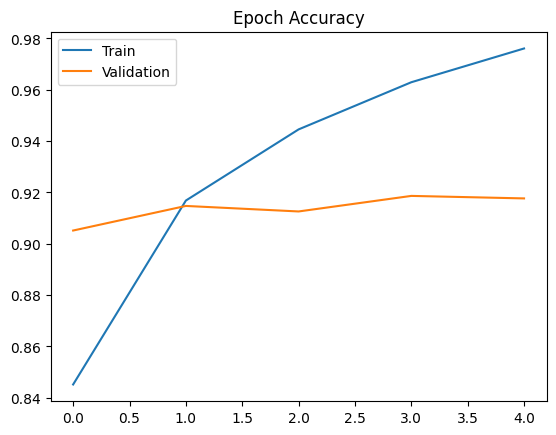

In [2]:
# ============================================
# Optimized Ensemble: BERT + XLM-R + DeBERTa
# ============================================

import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================
# Load Dataset
# ============================================

df = pd.read_csv("/kaggle/input/datasets/mdkamruzzaman2200/hate-speech-dataset/spelling_correct_with_removeNumber - spelling_correct_with_removeNumber.csv")

text_col = df.columns[0]
label_col = df.columns[1]

texts = df[text_col].astype(str).tolist()
labels = df[label_col].tolist()

num_classes = len(set(labels))

print("Dataset size:", len(texts))

# ============================================
# Train Validation Split
# ============================================

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# ============================================
# Class Weights
# ============================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

# ============================================
# Tokenizers
# ============================================

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
xlmr_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
deberta_tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-base")

MAX_LEN = 64

# ============================================
# Pre Tokenization
# ============================================

def tokenize_texts(tokenizer, texts):

    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

bert_train = tokenize_texts(bert_tokenizer, train_texts)
bert_val = tokenize_texts(bert_tokenizer, val_texts)

xlmr_train = tokenize_texts(xlmr_tokenizer, train_texts)
xlmr_val = tokenize_texts(xlmr_tokenizer, val_texts)

deberta_train = tokenize_texts(deberta_tokenizer, train_texts)
deberta_val = tokenize_texts(deberta_tokenizer, val_texts)

# ============================================
# Dataset
# ============================================

class EnsembleDataset(Dataset):

    def __init__(self, bert, xlmr, deberta, labels):

        self.bert = bert
        self.xlmr = xlmr
        self.deberta = deberta
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        return {

            "bert_ids": self.bert["input_ids"][idx],
            "bert_mask": self.bert["attention_mask"][idx],

            "xlmr_ids": self.xlmr["input_ids"][idx],
            "xlmr_mask": self.xlmr["attention_mask"][idx],

            "deberta_ids": self.deberta["input_ids"][idx],
            "deberta_mask": self.deberta["attention_mask"][idx],

            "label": self.labels[idx]
        }

train_dataset = EnsembleDataset(bert_train, xlmr_train, deberta_train, train_labels)
val_dataset = EnsembleDataset(bert_val, xlmr_val, deberta_val, val_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# ============================================
# Device
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================
# Models
# ============================================

bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_classes
).to(device)

xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=num_classes
).to(device)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-base",
    num_labels=num_classes
).to(device)

models = [bert_model, xlmr_model, deberta_model]

# ============================================
# Loss
# ============================================

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# ============================================
# Optimizers
# ============================================

optimizers = [
    torch.optim.AdamW(model.parameters(), lr=2e-5)
    for model in models
]

# ============================================
# Scheduler
# ============================================

total_steps = len(train_loader) * 5

schedulers = [
    get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
    for optimizer in optimizers
]

# ============================================
# Training
# ============================================

epochs = 5

train_acc_list = []
val_acc_list = []

for epoch in range(epochs):

    for model in models:
        model.train()

    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for batch in loop:

        labels_batch = batch["label"].to(device)

        bert_logits = bert_model(
            batch["bert_ids"].to(device),
            attention_mask=batch["bert_mask"].to(device)
        ).logits

        xlmr_logits = xlmr_model(
            batch["xlmr_ids"].to(device),
            attention_mask=batch["xlmr_mask"].to(device)
        ).logits

        deberta_logits = deberta_model(
            batch["deberta_ids"].to(device),
            attention_mask=batch["deberta_mask"].to(device)
        ).logits

        loss = (
            criterion(bert_logits, labels_batch) +
            criterion(xlmr_logits, labels_batch) +
            criterion(deberta_logits, labels_batch)
        ) / 3

        for opt in optimizers:
            opt.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            [p for model in models for p in model.parameters()],
            1.0
        )

        for opt in optimizers:
            opt.step()

        for sch in schedulers:
            sch.step()

        probs = (
            torch.softmax(bert_logits, dim=1) +
            torch.softmax(xlmr_logits, dim=1) +
            torch.softmax(deberta_logits, dim=1)
        ) / 3

        preds = torch.argmax(probs, dim=1)

        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    train_acc = correct / total
    train_acc_list.append(train_acc)

    # ============================================
    # Validation
    # ============================================

    for model in models:
        model.eval()

    correct = 0
    total = 0

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for batch in val_loader:

            labels_batch = batch["label"].to(device)

            bert_logits = bert_model(
                batch["bert_ids"].to(device),
                attention_mask=batch["bert_mask"].to(device)
            ).logits

            xlmr_logits = xlmr_model(
                batch["xlmr_ids"].to(device),
                attention_mask=batch["xlmr_mask"].to(device)
            ).logits

            deberta_logits = deberta_model(
                batch["deberta_ids"].to(device),
                attention_mask=batch["deberta_mask"].to(device)
            ).logits

            probs = (
                torch.softmax(bert_logits, dim=1) +
                torch.softmax(xlmr_logits, dim=1) +
                torch.softmax(deberta_logits, dim=1)
            ) / 3

            preds = torch.argmax(probs, dim=1)

            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

            y_true.extend(labels_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    val_acc = correct / total
    val_acc_list.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Val Acc: {val_acc:.4f}")

# ============================================
# Classification Report
# ============================================

print("\nClassification Report\n")
print(classification_report(y_true, y_pred))

# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================
# ROC Curve
# ============================================

y_prob = np.array(y_prob)

roc_auc = roc_auc_score(y_true, y_prob[:,1])

fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ============================================
# Accuracy Curve
# ============================================

plt.plot(train_acc_list,label="Train")
plt.plot(val_acc_list,label="Validation")
plt.legend()
plt.title("Epoch Accuracy")
plt.show()

# **Indonesian Dataset**

Dataset Columns: Index(['Source.Name', 'Column1', 'Column2', 'Date', 'Likes', 'Comment',
       '(view source)', 'Post ID', 'Label'],
      dtype='object')
Dataset size: 76566
Classes: 3


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


Epoch 3
Train Accuracy: 0.9688989747273559


100%|██████████| 3829/3829 [24:28<00:00,  2.61it/s]



Epoch 4
Train Accuracy: 0.9773558414419121


100%|██████████| 3829/3829 [24:31<00:00,  2.60it/s]



Epoch 5
Train Accuracy: 0.9813557108339319

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     12567
           1       0.89      0.94      0.91      2207
           2       0.88      0.91      0.90       540

    accuracy                           0.97     15314
   macro avg       0.92      0.94      0.93     15314
weighted avg       0.97      0.97      0.97     15314



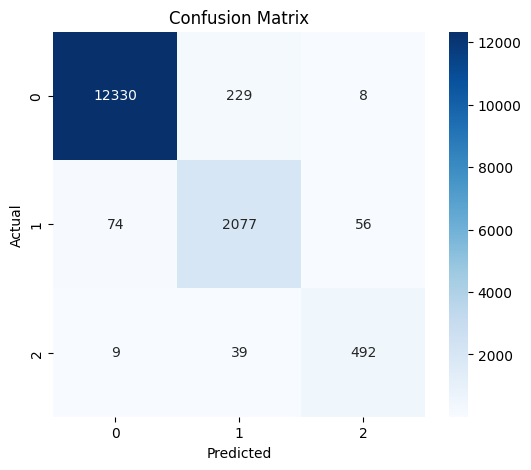

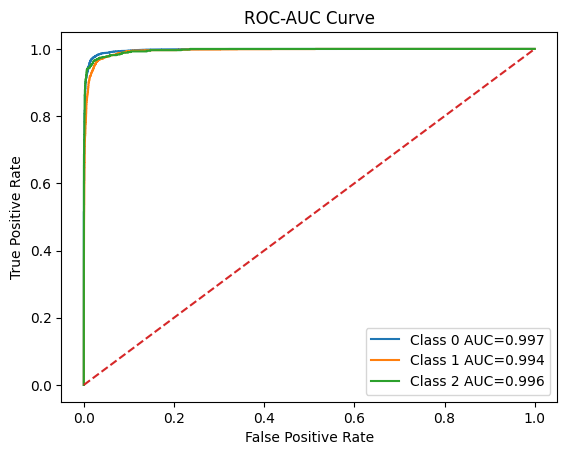

In [1]:
# ============================================
# Proposed Model: BERT + XLM-R + DeBERTa
# Indo Hate Speech Dataset
# ============================================

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================
# Load Dataset
# ============================================

df = pd.read_excel("/kaggle/input/datasets/mdkamruzzaman2200/indonesian/Indo-HateSpeech_Dataset.xlsx")

print("Dataset Columns:", df.columns)

text_col = "Comment"
label_col = "Label"

df = df[[text_col, label_col]].dropna()

texts = df[text_col].astype(str).tolist()
labels = pd.factorize(df[label_col])[0].tolist()

num_classes = len(set(labels))

print("Dataset size:", len(texts))
print("Classes:", num_classes)

# ============================================
# Train Validation Split
# ============================================

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# ============================================
# Class Weights
# ============================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

# ============================================
# Tokenizers
# ============================================

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
xlmr_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
deberta_tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-base")

MAX_LEN = 64

def tokenize(tokenizer, texts):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

bert_train = tokenize(bert_tokenizer, train_texts)
bert_val = tokenize(bert_tokenizer, val_texts)

xlmr_train = tokenize(xlmr_tokenizer, train_texts)
xlmr_val = tokenize(xlmr_tokenizer, val_texts)

deberta_train = tokenize(deberta_tokenizer, train_texts)
deberta_val = tokenize(deberta_tokenizer, val_texts)

# ============================================
# Dataset Class
# ============================================

class EnsembleDataset(Dataset):

    def __init__(self, bert, xlmr, deberta, labels):
        self.bert = bert
        self.xlmr = xlmr
        self.deberta = deberta
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        return {
            "bert_ids": self.bert["input_ids"][idx],
            "bert_mask": self.bert["attention_mask"][idx],

            "xlmr_ids": self.xlmr["input_ids"][idx],
            "xlmr_mask": self.xlmr["attention_mask"][idx],

            "deberta_ids": self.deberta["input_ids"][idx],
            "deberta_mask": self.deberta["attention_mask"][idx],

            "label": self.labels[idx]
        }

train_dataset = EnsembleDataset(bert_train, xlmr_train, deberta_train, train_labels)
val_dataset = EnsembleDataset(bert_val, xlmr_val, deberta_val, val_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# ============================================
# Device
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================
# Models
# ============================================

bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=num_classes).to(device)

xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=num_classes).to(device)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-base", num_labels=num_classes).to(device)

models = [bert_model, xlmr_model, deberta_model]

# ============================================
# Loss
# ============================================

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# ============================================
# Optimizers
# ============================================

optimizers = [
    torch.optim.AdamW(model.parameters(), lr=2e-5)
    for model in models
]

# ============================================
# Training
# ============================================

epochs = 5

for epoch in range(epochs):

    for model in models:
        model.train()

    total = 0
    correct = 0

    for batch in tqdm(train_loader):

        labels_batch = batch["label"].to(device)

        bert_logits = bert_model(
            batch["bert_ids"].to(device),
            attention_mask=batch["bert_mask"].to(device)
        ).logits

        xlmr_logits = xlmr_model(
            batch["xlmr_ids"].to(device),
            attention_mask=batch["xlmr_mask"].to(device)
        ).logits

        deberta_logits = deberta_model(
            batch["deberta_ids"].to(device),
            attention_mask=batch["deberta_mask"].to(device)
        ).logits

        loss = (
            criterion(bert_logits, labels_batch) +
            criterion(xlmr_logits, labels_batch) +
            criterion(deberta_logits, labels_batch)
        ) / 3

        for opt in optimizers:
            opt.zero_grad()

        loss.backward()

        for opt in optimizers:
            opt.step()

        probs = (
            torch.softmax(bert_logits, dim=1) +
            torch.softmax(xlmr_logits, dim=1) +
            torch.softmax(deberta_logits, dim=1)
        ) / 3

        preds = torch.argmax(probs, dim=1)

        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    print(f"\nEpoch {epoch+1}")
    print("Train Accuracy:", correct / total)

# ============================================
# Validation
# ============================================

y_true = []
y_pred = []
y_prob = []

for model in models:
    model.eval()

with torch.no_grad():

    for batch in val_loader:

        labels_batch = batch["label"].to(device)

        bert_logits = bert_model(
            batch["bert_ids"].to(device),
            attention_mask=batch["bert_mask"].to(device)
        ).logits

        xlmr_logits = xlmr_model(
            batch["xlmr_ids"].to(device),
            attention_mask=batch["xlmr_mask"].to(device)
        ).logits

        deberta_logits = deberta_model(
            batch["deberta_ids"].to(device),
            attention_mask=batch["deberta_mask"].to(device)
        ).logits

        probs = (
            torch.softmax(bert_logits, dim=1) +
            torch.softmax(xlmr_logits, dim=1) +
            torch.softmax(deberta_logits, dim=1)
        ) / 3

        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

# ============================================
# Classification Report
# ============================================

print("\nClassification Report\n")
print(classification_report(y_true, y_pred))

# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================
# ROC-AUC Curve
# ============================================

y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
y_prob = np.array(y_prob)

plt.figure()

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    auc_score = roc_auc_score(y_true_bin[:, i], y_prob[:, i])

    plt.plot(fpr, tpr, label=f"Class {i} AUC={auc_score:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")

plt.legend()
plt.show()

# **English Dataset**

Dataset size: 24783
Classes: 2


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


Epoch 3
Train Accuracy: 0.9668
Validation Accuracy: 0.9623


100%|██████████| 1240/1240 [07:53<00:00,  2.62it/s]



Epoch 4
Train Accuracy: 0.9787
Validation Accuracy: 0.9661


100%|██████████| 1240/1240 [07:53<00:00,  2.62it/s]



Epoch 5
Train Accuracy: 0.9858
Validation Accuracy: 0.9572

Classification Report

              precision    recall  f1-score   support

           0       0.81      0.97      0.88       833
           1       0.99      0.96      0.97      4124

    accuracy                           0.96      4957
   macro avg       0.90      0.96      0.93      4957
weighted avg       0.96      0.96      0.96      4957



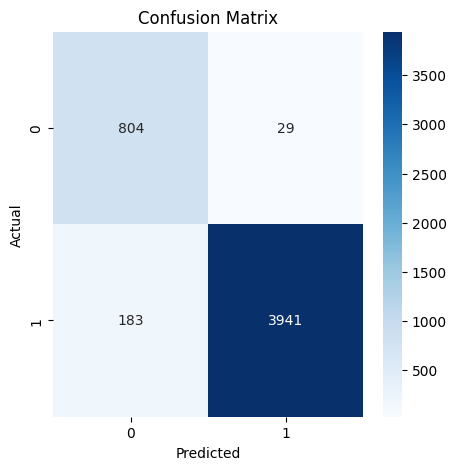

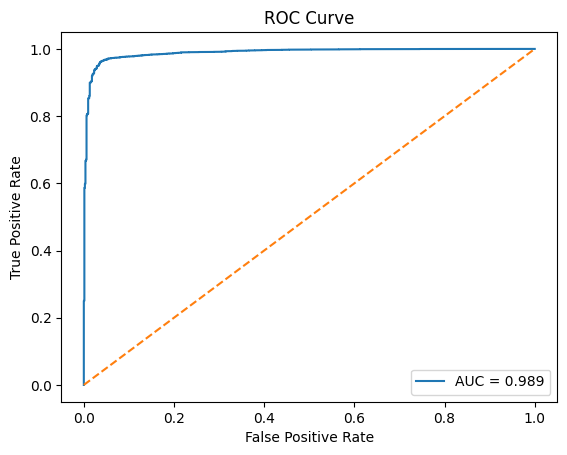

In [1]:
# ============================================
# Proposed Model: BERT + XLM-R + DeBERTa
# English Hate Speech Dataset (Binary)
# ============================================

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================
# Load English Dataset
# ============================================

df = pd.read_csv("/kaggle/input/datasets/mdkamruzzaman2200/english-dataset/labeled_data.csv")

text_col = "tweet"

# Convert 3-class → binary
df["target"] = df["class"].apply(lambda x: 0 if x == 2 else 1)

texts = df[text_col].astype(str).tolist()
labels = df["target"].tolist()

num_classes = 2

print("Dataset size:", len(texts))
print("Classes:", num_classes)

# ============================================
# Train Validation Split
# ============================================

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# ============================================
# Class Weights
# ============================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

# ============================================
# Tokenizers
# ============================================

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
xlmr_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
deberta_tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-base")

MAX_LEN = 64

def tokenize(tokenizer, texts):

    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

bert_train = tokenize(bert_tokenizer, train_texts)
bert_val = tokenize(bert_tokenizer, val_texts)

xlmr_train = tokenize(xlmr_tokenizer, train_texts)
xlmr_val = tokenize(xlmr_tokenizer, val_texts)

deberta_train = tokenize(deberta_tokenizer, train_texts)
deberta_val = tokenize(deberta_tokenizer, val_texts)

# ============================================
# Dataset Class
# ============================================

class EnsembleDataset(Dataset):

    def __init__(self, bert, xlmr, deberta, labels):

        self.bert = bert
        self.xlmr = xlmr
        self.deberta = deberta
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        return {

            "bert_ids": self.bert["input_ids"][idx],
            "bert_mask": self.bert["attention_mask"][idx],

            "xlmr_ids": self.xlmr["input_ids"][idx],
            "xlmr_mask": self.xlmr["attention_mask"][idx],

            "deberta_ids": self.deberta["input_ids"][idx],
            "deberta_mask": self.deberta["attention_mask"][idx],

            "label": self.labels[idx]
        }

train_dataset = EnsembleDataset(bert_train, xlmr_train, deberta_train, train_labels)
val_dataset = EnsembleDataset(bert_val, xlmr_val, deberta_val, val_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# ============================================
# Device
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================
# Models (UNCHANGED)
# ============================================

bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_classes
).to(device)

xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=num_classes
).to(device)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-base",
    num_labels=num_classes
).to(device)

models = [bert_model, xlmr_model, deberta_model]

# ============================================
# Loss
# ============================================

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# ============================================
# Optimizers
# ============================================

optimizers = [
    torch.optim.AdamW(model.parameters(), lr=2e-5)
    for model in models
]

# ============================================
# Training + Validation Accuracy
# ============================================

epochs = 5

for epoch in range(epochs):

    # ----- Training -----
    for model in models:
        model.train()

    train_total = 0
    train_correct = 0

    for batch in tqdm(train_loader):

        labels_batch = batch["label"].to(device)

        bert_logits = bert_model(
            batch["bert_ids"].to(device),
            attention_mask=batch["bert_mask"].to(device)
        ).logits

        xlmr_logits = xlmr_model(
            batch["xlmr_ids"].to(device),
            attention_mask=batch["xlmr_mask"].to(device)
        ).logits

        deberta_logits = deberta_model(
            batch["deberta_ids"].to(device),
            attention_mask=batch["deberta_mask"].to(device)
        ).logits

        loss = (
            criterion(bert_logits, labels_batch) +
            criterion(xlmr_logits, labels_batch) +
            criterion(deberta_logits, labels_batch)
        ) / 3

        for opt in optimizers:
            opt.zero_grad()

        loss.backward()

        for opt in optimizers:
            opt.step()

        probs = (
            torch.softmax(bert_logits, dim=1) +
            torch.softmax(xlmr_logits, dim=1) +
            torch.softmax(deberta_logits, dim=1)
        ) / 3

        preds = torch.argmax(probs, dim=1)

        train_correct += (preds == labels_batch).sum().item()
        train_total += labels_batch.size(0)

    train_acc = train_correct / train_total

    # ----- Validation -----
    for model in models:
        model.eval()

    val_total = 0
    val_correct = 0

    with torch.no_grad():

        for batch in val_loader:

            labels_batch = batch["label"].to(device)

            bert_logits = bert_model(
                batch["bert_ids"].to(device),
                attention_mask=batch["bert_mask"].to(device)
            ).logits

            xlmr_logits = xlmr_model(
                batch["xlmr_ids"].to(device),
                attention_mask=batch["xlmr_mask"].to(device)
            ).logits

            deberta_logits = deberta_model(
                batch["deberta_ids"].to(device),
                attention_mask=batch["deberta_mask"].to(device)
            ).logits

            probs = (
                torch.softmax(bert_logits, dim=1) +
                torch.softmax(xlmr_logits, dim=1) +
                torch.softmax(deberta_logits, dim=1)
            ) / 3

            preds = torch.argmax(probs, dim=1)

            val_correct += (preds == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    val_acc = val_correct / val_total

    print(f"\nEpoch {epoch+1}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

# ============================================
# Final Evaluation
# ============================================

y_true = []
y_pred = []
y_prob = []

for model in models:
    model.eval()

with torch.no_grad():

    for batch in val_loader:

        labels_batch = batch["label"].to(device)

        bert_logits = bert_model(
            batch["bert_ids"].to(device),
            attention_mask=batch["bert_mask"].to(device)
        ).logits

        xlmr_logits = xlmr_model(
            batch["xlmr_ids"].to(device),
            attention_mask=batch["xlmr_mask"].to(device)
        ).logits

        deberta_logits = deberta_model(
            batch["deberta_ids"].to(device),
            attention_mask=batch["deberta_mask"].to(device)
        ).logits

        probs = (
            torch.softmax(bert_logits, dim=1) +
            torch.softmax(xlmr_logits, dim=1) +
            torch.softmax(deberta_logits, dim=1)
        ) / 3

        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs[:,1].cpu().numpy())

print("\nClassification Report\n")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc_auc = roc_auc_score(y_true, y_prob)
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()